In [85]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [164]:
# --- 1. Load data ---
ticker = "^GSPC"
sp500 = yf.Ticker(ticker)
data = sp500.history(period="3y")["Close"]
data = data.dropna()
train_size = int(len(data) * 0.85)
base_train = data[0]
base_test = data[train_size]
#data = data.diff()[1:]/np.array(data[:-1])
data = np.log(data[1:] / np.array(data[:-1]))

def vol(lag):
    vol_data = pd.DataFrame({'vol':[np.std(data[i:lag+i]) for i in range(data.shape[0]-lag)]})# data[20:].index
    vol_data.index = data[lag:].index
    return vol_data

In [165]:
def GRL_sigma(data, t):
    G_list = []
    for k in range(2, t-2):
        sigma_1 = np.var(data[:k])
        sigma_2 = np.var(data[k:t])
        sigma = np.var(data[:t])
        C = 1 + (1/(k-1)+1/(t-k-1)-1/(t-2))/3
        G_kt = ((k-1)*np.log(sigma/sigma_1) + (t-k-1)*np.log(sigma/sigma_2)) / C
        G_list.append(G_kt)
        
    return np.max(G_list)

In [166]:
#G_test = [GRL_sigma(data, t) for t in range(5,1000)]

In [167]:
def GRL_sigma_sec(data, t, h):
    data_aux = data.copy()
    tau_list = []
    G_list = []
    s_prev = 0
    for s in tqdm(range(t-5)):
        G = GRL_sigma(data_aux, s-s_prev+5)
        G_list.append(G)
        if G > h:
            data_aux = data[s:]
            tau_list.append(s)
            s_prev = s
    return tau_list, G_list

In [189]:
tau_list, G_list = GRL_sigma_sec(data, t=data.shape[0], h=7)
tau_list = [0] + tau_list

100%|████████████████████████████████████████| 746/746 [00:02<00:00, 370.54it/s]


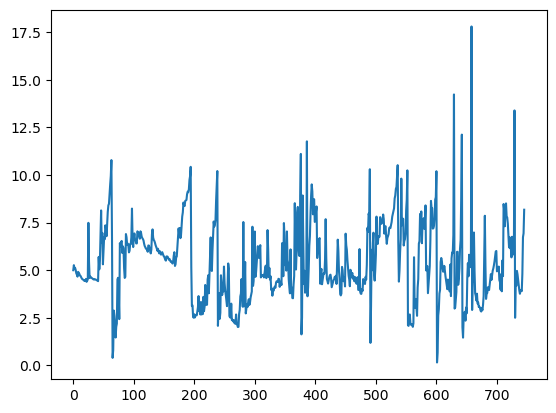

In [169]:
plt.plot(G_list)

[0.007415034795453906,
 0.0074842010638548504,
 0.006749810065414371,
 0.006409337666813418,
 0.004564257741652669,
 0.011226013456783007,
 0.00512817189652153,
 0.010535832296694771,
 0.003916054567353742,
 0.010183076701920722]

In [179]:
[base_train*np.exp(np.sum(data[tau_list[i]:tau_list[i+1]])) for i in range(len(tau_list)-1)]

[4118.6298828125,
 4177.446806704575,
 4060.435033869761,
 4157.598708458013,
 4430.853636786803,
 4794.659385167102,
 4425.182301096903,
 4228.559972254886,
 4204.2547096603685,
 4204.268663658329,
 4188.752910647624,
 4265.535870010919,
 3866.4735745816015]

In [185]:

ret_taus

[-0.2599273803620233,
 -0.25418333392096504,
 -0.2590146341915885,
 -0.26731243937252586,
 -0.20942542418388052,
 -0.016256081982710443,
 0.2225455224615341,
 0.3399319807665626,
 0.395270200007284,
 0.4445475800443001,
 0.4900509087491877,
 0.5593855297982245,
 0.5063857434812901]

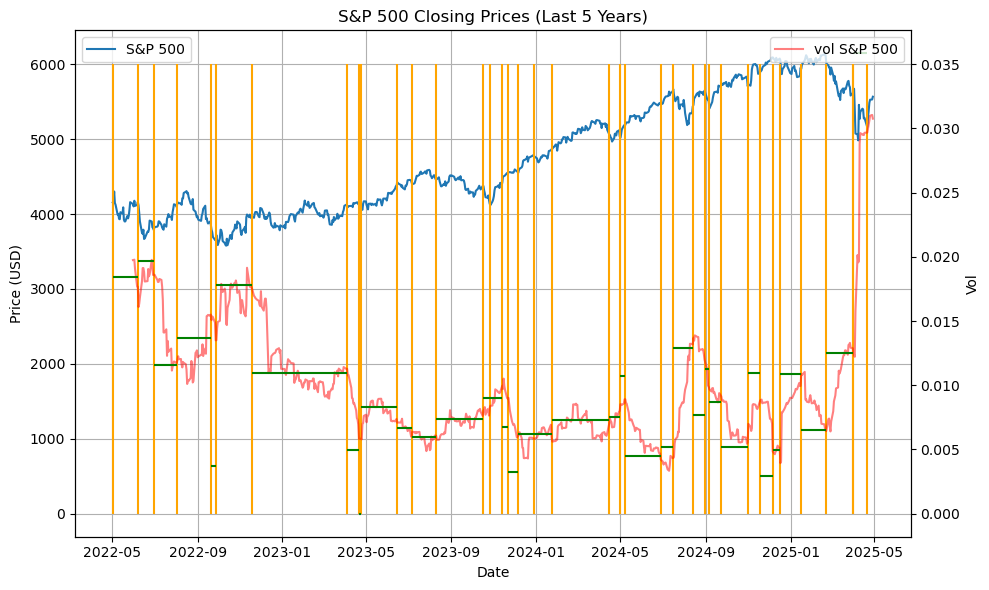

In [190]:
# Optional: Plot the closing price
fig, ax1 = plt.subplots(figsize=(10, 6))

#plt.figure(figsize=(10, 6))
ax1.plot(data.index, base_train*np.exp(np.cumsum(data)), label="S&P 500")
ax1.set_title("S&P 500 Closing Prices (Last 5 Years)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True)

for tau in tau_list:
    ax1.vlines(data.index[tau], ymin=0, ymax=6000, color='orange')

ax2 = ax1.twinx()

vol_data = vol(20)
vol_taus = [np.std(data[tau_list[i]:tau_list[i+1]]) for i in range(len(tau_list)-1)]
ret_taus = [(np.exp(np.sum(data[:tau_list[i+1]]))-np.exp(np.sum(data[tau_list[i]:])))/np.exp(np.sum(data[tau_list[i]:])) for i in range(len(tau_list)-1)]

ax2.plot(vol_data, c='r', alpha=.5, label="vol S&P 500")
for i in range(len(vol_taus)):
    ax2.hlines(vol_taus[i], xmin=data.index[tau_list[i]],xmax=data.index[tau_list[i+1]], color='green')
    #ax2.hlines(ret_taus[i], xmin=data.index[tau_list[i]],xmax=data.index[tau_list[i+1]], color='black')

ax2.set_ylabel("Vol")
ax2.legend()


fig.tight_layout()

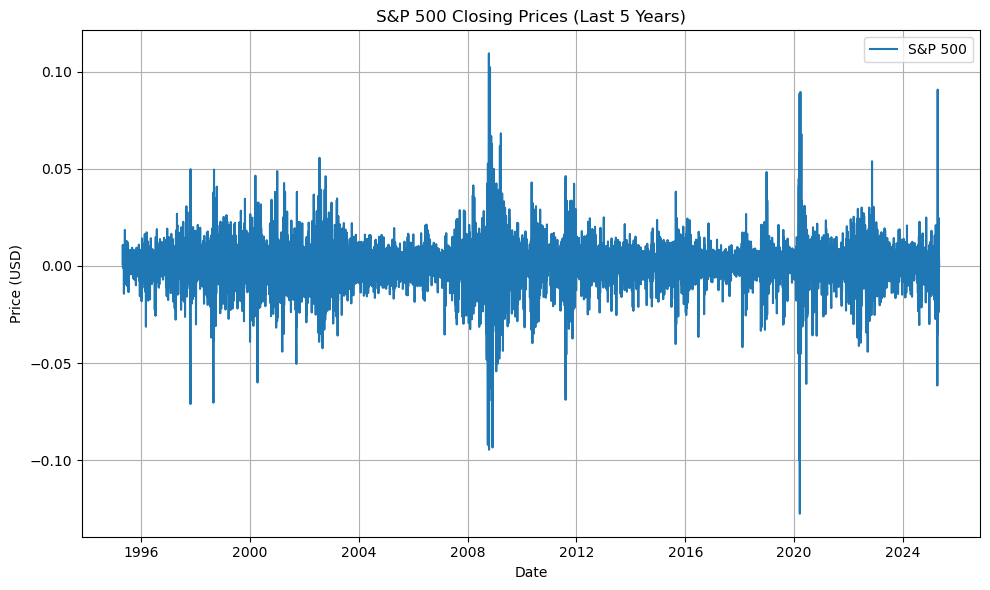

In [13]:
# Optional: Plot the closing price
plt.figure(figsize=(10, 6))
plt.plot(data.index, data, label="S&P 500")
plt.title("S&P 500 Closing Prices (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()

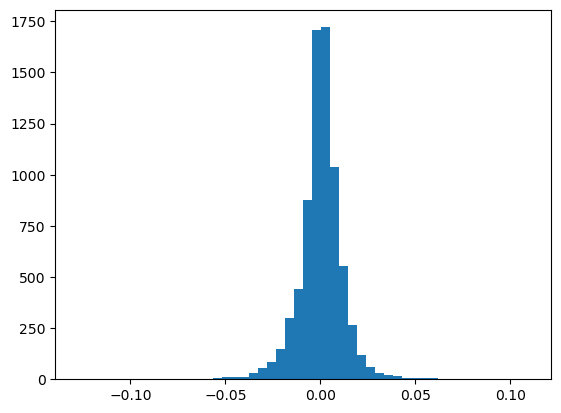

In [14]:
_ = plt.hist(data, bins=50)

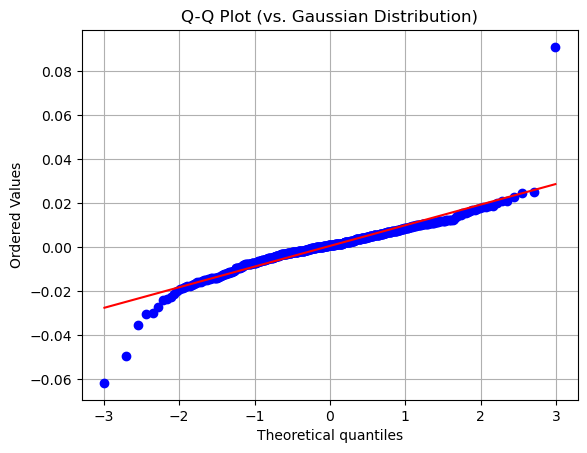

In [22]:

# Sample data (replace this with your data)
#data = np.random.normal(loc=0, scale=1, size=100)

# Create Q-Q plot
stats.probplot(data[-500:], dist="norm", plot=plt)
plt.title("Q-Q Plot (vs. Gaussian Distribution)")
plt.grid(True)
plt.show()
